In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [6]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

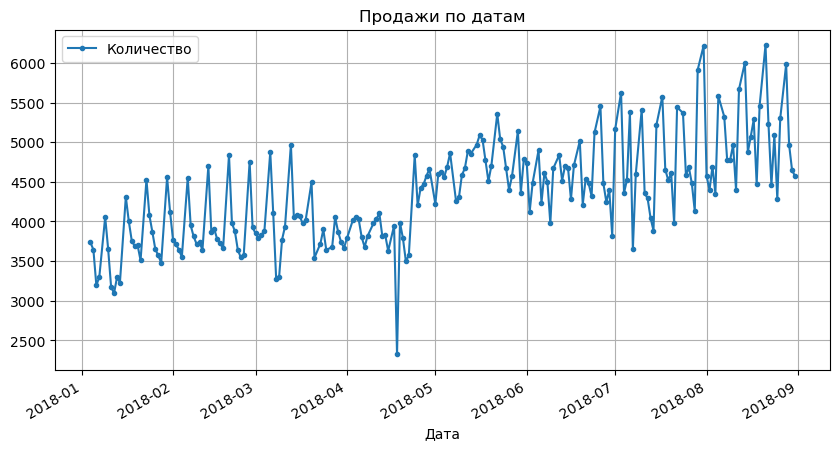

In [8]:
grouped_df.plot(x='Дата', y='Количество', marker='.', figsize=(10, 5))

plt.title('Продажи по датам')
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике видно, что продажи с января по апрель были относительно стабильны, но к маю они резко упали. Возможно в данных есть выбросы. Далее до сентября мы видим умеренный рост продаж.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
Q1 = df['Количество'].quantile(0.25)
Q3 = df['Количество'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['Количество'] > upper_bound]
max_outlier_row = outliers.loc[outliers['Количество'].idxmax()]

print(max_outlier_row)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
summer_wednesdays = df[(df['Склад'] == 3) & (df['Дата'].dt.month.isin([6, 7, 8])) & (df['Дата'].dt.dayofweek == 2)]
top_product = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().idxmax()
total_sales = summer_wednesdays.groupby('Номенклатура')['Количество'].sum().max()
print(f"Топовый товар: {top_product}, Продано: {total_sales}")

Топовый товар: product_1, Продано: 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [11]:
print(df['Дата'].min())
print(df['Дата'].max())

2018-01-04 00:00:00
2018-08-31 00:00:00


In [12]:
df_weather = pd.read_csv(
    'Данные о погоде.csv', 
    sep=';', 
    skiprows=6, 
    quotechar='"', 
    index_col=False, 
    encoding='utf-8'
)
df_weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN


In [13]:
weather_df = df_weather[['Местное время в Астане', 'T']]

In [14]:
weather_df.head()

,Местное время в Астане,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [21]:
weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'], dayfirst=True)

C:\Users\Askhat\AppData\Local\Temp\ipykernel_8456\2631392476.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_df['Местное время в Астане'] = pd.to_datetime(weather_df['Местное время в Астане'], dayfirst=True)


In [22]:
daily_weather = weather_df.groupby('Местное время в Астане')['T'].mean().reset_index()
print(daily_weather.head())

  Местное время в Астане        T
0             2018-01-04 -14.0750
1             2018-01-05 -16.8625
2             2018-01-06 -13.3000
3             2018-01-07 -12.7500
4             2018-01-08 -15.4125


In [23]:
daily_weather = daily_weather.rename(columns={'Местное время в Астане': 'Дата'})

In [24]:
final_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')

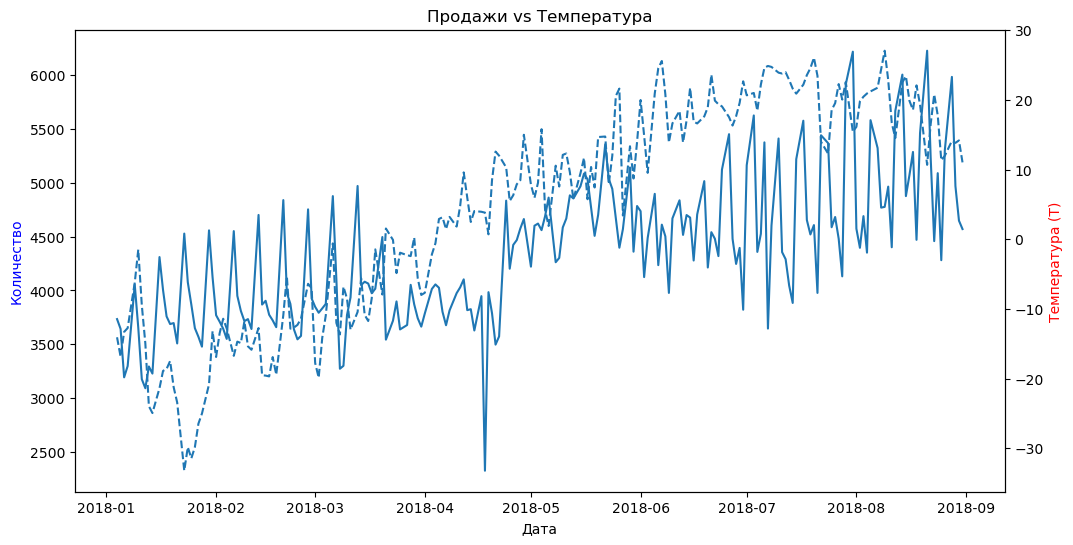

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество', color='blue')
ax1.plot(final_df ['Дата'], final_df ['Количество'], label='Продажи')

ax2 = ax1.twinx() 
ax2.set_ylabel('Температура (T)', color='red')
ax2.plot(final_df ['Дата'], final_df ['T'], linestyle='--', label='Температура')

plt.title('Продажи vs Температура')
plt.show()

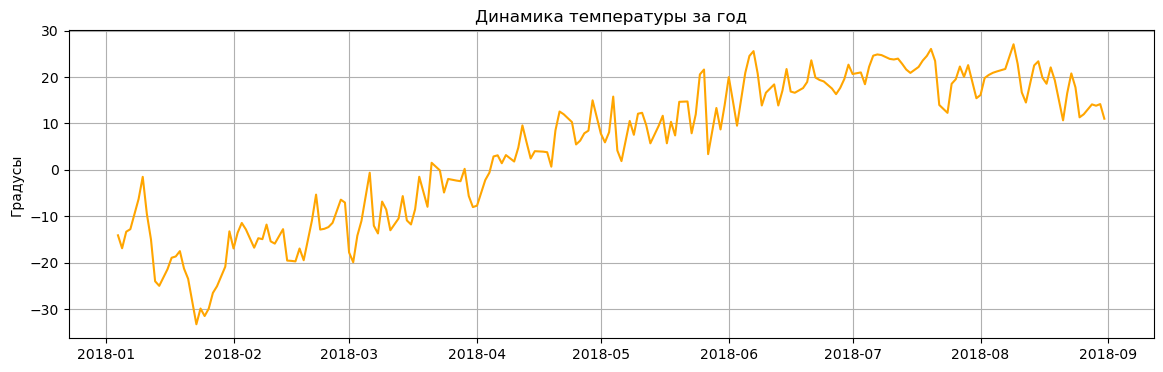

In [28]:
plt.figure(figsize=(14, 4))
plt.plot(final_df['Дата'], final_df['T'], color='orange')
plt.title('Динамика температуры за год')
plt.ylabel('Градусы')
plt.grid(True)
plt.show()